# 第40篇｜最小二乘法：模型是怎么拟合出来的？

> 这是「数据分析从入门到精通」系列的第 40 篇。一元线性回归会用了，但背后的原理是什么？这篇来聊最小二乘法——模型到底是怎么"拟合"出来的？搞懂了这个，后面所有的回归方法都会更容易理解。

---

嗨，我是小荷～

上一篇我们用 sklearn 一行代码就拟合好了线性回归，但你有没有想过：sklearn 的 `fit()` 背后到底在算什么？

今天我们"手推"一次最小二乘法（OLS），搞清楚截距 β₀ 和斜率 β₁ 的计算公式是怎么来的。

这不只是数学练习——理解了原理，你才能知道什么时候模型会出问题，以及为什么。

> 萧何管粮草，不只是会记账，他还懂每个数字的来龙去脉。我们学数据分析也一样——不只会调用 API，还要懂背后的逻辑。

---

## 一、最小二乘法的目标

给定 n 个数据点 (x₁,y₁), ..., (xₙ,yₙ)，找 β₀ 和 β₁ 使残差平方和（RSS）最小。

In [ ]:
RSS = Σ(yᵢ - ŷᵢ)² = Σ(yᵢ - β₀ - β₁xᵢ)²


对 RSS 分别对 β₀ 和 β₁ 求偏导，令导数为 0，得到：


In [ ]:
β₁ = Σ(xᵢ - x̄)(yᵢ - ȳ) / Σ(xᵢ - x̄)²  =  Cov(x,y) / Var(x)   # 斜率
β₀ = ȳ - β₁ · x̄   # 截距

---

## 二、手推实现

用代码把最小二乘法一步步实现出来，比直接调库理解深多了：


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']   # 文泉驿微米黑
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(42)

# 小样本验证
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=float)
y = 3 * x + 5 + np.random.normal(0, 2, 10)

# ── 手动计算 ──
x_bar = x.mean()
y_bar = y.mean()

# 协方差 Cov(x,y)
cov_xy = np.sum((x - x_bar) * (y - y_bar))
# 方差 Var(x)
var_x  = np.sum((x - x_bar) ** 2)

beta1 = cov_xy / var_x
beta0 = y_bar - beta1 * x_bar

print("手动最小二乘法：")
print(f"x̄ = {x_bar:.2f}, ȳ = {y_bar:.2f}")
print(f"Cov(x,y) = {cov_xy:.2f}, Var(x) = {var_x:.2f}")
print(f"β₁（斜率） = {beta1:.4f}")
print(f"β₀（截距） = {beta0:.4f}")

# 对比 numpy 结果
beta1_np, beta0_np = np.polyfit(x, y, 1)
print(f"\nnumpy polyfit：β₁ = {beta1_np:.4f}, β₀ = {beta0_np:.4f}")
print(f"误差（几乎为0）：β₁差 {abs(beta1-beta1_np):.8f}")


手动最小二乘法：
x̄ = 5.50, ȳ = 22.40
Cov(x,y) = 246.36, Var(x) = 82.50
β₁（斜率） = 2.9862
β₀（截距） = 5.9720

numpy polyfit：β₁ = 2.9862, β₀ = 5.9720
误差（几乎为0）：β₁差 0.00000000


---

## 三、梯度下降视角（入门）

最小二乘法有解析解（上面的公式），但在多元回归和神经网络中，通常用**梯度下降**来迭代求解。



梯度下降结果：β₀ = 5.3097, β₁ = 3.0813


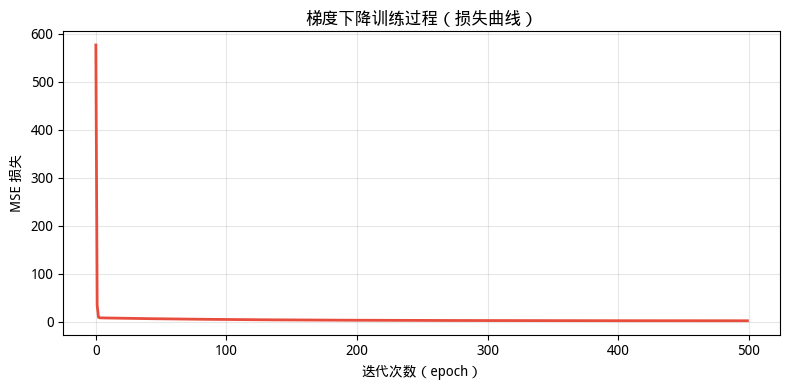

In [2]:
# 梯度下降实现一元线性回归
def gradient_descent(x, y, learning_rate=0.01, epochs=1000):
    n = len(x)
    b0, b1 = 0.0, 0.0   # 初始化参数
    history = []

    for epoch in range(epochs):
        # 预测
        y_pred = b0 + b1 * x
        # 计算损失（MSE）
        loss = np.mean((y - y_pred) ** 2)
        history.append(loss)
        # 计算梯度
        grad_b0 = -2/n * np.sum(y - y_pred)
        grad_b1 = -2/n * np.sum((y - y_pred) * x)
        # 更新参数
        b0 -= learning_rate * grad_b0
        b1 -= learning_rate * grad_b1

    return b0, b1, history

b0_gd, b1_gd, loss_history = gradient_descent(x, y, learning_rate=0.01, epochs=500)

print(f"\n梯度下降结果：β₀ = {b0_gd:.4f}, β₁ = {b1_gd:.4f}")

# 画损失曲线
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_history, color='#E74C3C', linewidth=2)
ax.set_title('梯度下降训练过程（损失曲线）', fontweight='bold')
ax.set_xlabel('迭代次数（epoch）')
ax.set_ylabel('MSE 损失')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


-  梯度下降：为什么梯度是 -2/n ？

一、先锁定核心：我们用的损失函数
代码里用的是 MSE 均方误差损失（回归任务标准损失）
模型预测：$$y_{pred} = b_0 + b_1 x$$
MSE损失公式：
$$L(b_0,b_1) = \frac{1}{n}\sum_{i=1}^n (y_i - y_{pred})^2$$
梯度下降的核心：对 \(b_0、b_1\) 求偏导，得到梯度，再更新参数。

---
二、推导：对 b0 求偏导（对应代码 grad_b0）
$$L = \frac{1}{n}\sum (y - (b_0 + b_1 x))^2$$
根据复合函数求导链式法则：
外层求导：$$2(y-y_{pred})$$
内层对 \(b_0\) 求导：$$\frac{\partial (y-b_0-b_1x)}{\partial b_0} = -1$$
带入均值公式的 $$\frac{1}{n}$$：
$$\frac{\partial L}{\partial b_0} = \frac{1}{n}\sum \big[2(y-y_{pred})\cdot(-1)\big]$$
合并常数：
$$\frac{\partial L}{\partial b_0} = \boldsymbol{-\frac{2}{n}\sum (y-y_{pred})}$$
完全对应代码第一行梯度：grad_b0 = -2/n * np.sum(y - y_pred)

---
三、推导：对 b1 求偏导（对应代码 grad_b1）
同样链式求导，唯一区别：内层对 $$b_1$$ 求导
内层导数：$$\frac{\partial (y-b_0-b_1x)}{\partial b_1} = -x$$
完整偏导：
$$\frac{\partial L}{\partial b_1} = \frac{1}{n}\sum \big[2(y-y_{pred})\cdot(-x)\big]$$
整理得：
$$\frac{\partial L}{\partial b_1} = \boldsymbol{-\frac{2}{n}\sum (y-y_{pred})\cdot x}$$
完全对应代码第二行梯度：grad_b1 = -2/n * np.sum((y - y_pred) * x)

---
四、逐字符拆解：-2/n 每一部分的意义
- 2：平方项求导自带的系数 \((u^2)'=2u\)
- 负号：内层函数求导产生（真实值-预测值对参数求导为-1/-x）
- 1/n：MSE 是「均值误差」，必须除以样本总数，保证梯度尺度和样本量无关
✅ 三者合并：-2/n

---
五、关键答疑：为什么必须带负号？（梯度下降核心）
参数更新公式：$$b = b - lr \times grad$$
梯度方向是损失上升最快的方向，我们要减小损失，必须 逆着梯度走。
公式里的负号，就是实现：反向更新、降低损失。

---
六、总结
1. 2：平方损失函数求导自带系数；
2. 负号：链式求导内层产生，保证参数往损失减小的方向更新；
3. /n：MSE均值归一化，让梯度大小不受样本数量影响，学习率稳定通用。

---

## 四、矩阵形式（多元回归的基础）

对于多元线性回归，最小二乘法可以用矩阵表示：


In [ ]:
β = (X^T X)^{-1} X^T y


公式看着有点抽象？没关系，我先解释一下，然后再用代码来实现一下，就清晰了：

我们把公式 $\beta = (X^T X)^{-1} X^T y$ 拆成三部分来看：
1. $X$ 和 $y$ 是什么？（你的原始数据）$X$ 是特征矩阵（输入数据）。在你的代码里，它包含了广告投入的数据（为了算截距，通常还会人为加上一列全为 $1$ 的列）。$y$ 是标签向量（预测目标）。在你的代码里，它就是实际的销售额。
2. $X^T$ 是什么？（矩阵转置）$T$ 代表转置（Transpose）。就是把矩阵的行和列对调（横着的变竖着，竖着的变横着）。为什么要转置？因为在矩阵乘法里，两个矩阵的形状必须匹配才能相乘。
3. $()^{-1}$ 是什么？（矩阵的逆）在普通数字里， $5^{-1}$ 就是 $\frac{1}{5}$。在矩阵里， $^{-1}$ 代表求逆矩阵（Inverse），你可以粗暴地把它理解为“矩阵里的除法”。

In [3]:
# 矩阵实现（为多元回归做铺垫）
n_data = 100
np.random.seed(42)
x_big = np.random.uniform(1, 10, n_data)
y_big = 5 + 3.2 * x_big + np.random.normal(0, 3, n_data)

# 添加截距列（全1列）
X_mat = np.column_stack([np.ones(n_data), x_big])   # 形状 (n, 2)
y_vec = y_big.reshape(-1, 1)                          # 形状 (n, 1)

# β = (X^T X)^{-1} X^T y
beta = np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T @ y_vec
print(f"\n矩阵法结果：β₀ = {beta[0][0]:.4f}, β₁ = {beta[1][0]:.4f}")

# 验证：等价于 sklearn
from sklearn.linear_model import LinearRegression
sk = LinearRegression().fit(x_big.reshape(-1,1), y_big)
print(f"sklearn 结果：β₀ = {sk.intercept_:.4f}, β₁ = {sk.coef_[0]:.4f}")



矩阵法结果：β₀ = 5.7985, β₁ = 3.0467
sklearn 结果：β₀ = 5.7985, β₁ = 3.0467


---

## 五、β₁ 的统计检验

知道了 β₁ 的计算方法，还需要检验它是否显著（不等于 0）：


In [4]:
import statsmodels.api as sm

X_sm = sm.add_constant(x_big)
model_sm = sm.OLS(y_big, X_sm).fit()
print("\nstatsmodels OLS 摘要：")
print(model_sm.summary().tables[1])   # 只打印系数表

# 手动计算 t 统计量
residuals = y_big - (beta[0][0] + beta[1][0] * x_big)
s2 = np.sum(residuals**2) / (n_data - 2)   # 残差方差
se_beta1 = np.sqrt(s2 / np.sum((x_big - x_big.mean())**2))

t_manual = beta[1][0] / se_beta1
from scipy import stats
p_manual = 2 * (1 - stats.t.cdf(abs(t_manual), df=n_data-2))

print(f"\n手动 t 检验：t = {t_manual:.4f}，p = {p_manual:.6f}")
print(f"（等价于 statsmodels 的 t 和 P>|t|）")



statsmodels OLS 摘要：
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.7985      0.600      9.668      0.000       4.608       6.989
x1             3.0467      0.102     29.822      0.000       2.844       3.249

手动 t 检验：t = 29.8218，p = 0.000000
（等价于 statsmodels 的 t 和 P>|t|）


---

## 六、📝 小结

| 知识点 | 内容 |
|--------|------|
| OLS 目标 | 最小化残差平方和 RSS |
| β₁ 公式 | Cov(x,y) / Var(x) |
| β₀ 公式 | ȳ - β₁x̄ |
| 梯度下降 | 迭代法，适合大规模多元回归 |
| 矩阵形式 | β = (X^T X)^{-1} X^T y |
| t 检验 | 判断系数是否显著不为 0 |

理解了这些，你就从"会用工具"升级到了"理解原理"。下次看到 p 值、R² 的时候，你知道它们是怎么算出来的了。

---

## 七、🏋️ 课后练习

1. 用 5 个数据点手动算 β₀ 和 β₁，然后与 sklearn 的结果对比验证。
2. 把学习率从 0.01 改成 0.1 和 0.001，观察梯度下降的收敛速度有何不同。
3. 用矩阵公式 β = (X^T X)^{-1} X^T y 实现多元线性回归（含两个自变量），验证与 sklearn 结果一致。

In [5]:
print("练习1：最小二乘法手动计算 vs sklearn")

# 构造5个数据点
X = np.array([1, 2, 3, 4, 5])
y = np.array([2.1, 4.2, 5.8, 8.1, 10.2])

print("\n5个数据点：")
for i in range(len(X)):
    print(f"  点{i+1}: x={X[i]}, y={y[i]}")

# 手动计算 β₁ 和 β₀（最小二乘法公式）
n = len(X)
x_mean = np.mean(X)
y_mean = np.mean(y)

# β₁ = Σ(x-x̄)(y-ȳ) / Σ(x-x̄)²
numerator = np.sum((X - x_mean) * (y - y_mean))
denominator = np.sum((X - x_mean) ** 2)
beta_1_manual = numerator / denominator

# β₀ = ȳ - β₁ * x̄
beta_0_manual = y_mean - beta_1_manual * x_mean

print(f"\n手动计算结果：")
print(f"β₁ (斜率) = {beta_1_manual:.6f}")
print(f"β₀ (截距) = {beta_0_manual:.6f}")

# 使用sklearn计算
model = LinearRegression()
X_reshape = X.reshape(-1, 1)
model.fit(X_reshape, y)
beta_1_sklearn = model.coef_[0]
beta_0_sklearn = model.intercept_

print(f"\nsklearn计算结果：")
print(f"β₁ (斜率) = {beta_1_sklearn:.6f}")
print(f"β₀ (截距) = {beta_0_sklearn:.6f}")

# 验证两者是否一致
print(f"\n验证：")
print(f"β₁ 差异: {abs(beta_1_manual - beta_1_sklearn):.10f}")
print(f"β₀ 差异: {abs(beta_0_manual - beta_0_sklearn):.10f}")
if abs(beta_1_manual - beta_1_sklearn) < 1e-10:
    print("✓ 手动计算与sklearn结果完全一致！")

练习1：最小二乘法手动计算 vs sklearn

5个数据点：
  点1: x=1, y=2.1
  点2: x=2, y=4.2
  点3: x=3, y=5.8
  点4: x=4, y=8.1
  点5: x=5, y=10.2

手动计算结果：
β₁ (斜率) = 2.010000
β₀ (截距) = 0.050000

sklearn计算结果：
β₁ (斜率) = 2.010000
β₀ (截距) = 0.050000

验证：
β₁ 差异: 0.0000000000
β₀ 差异: 0.0000000000
✓ 手动计算与sklearn结果完全一致！


练习2：梯度下降学习率实验

梯度下降收敛实验（最大迭代次数=200）：
----------------------------------------

学习率 α = 0.01:
  最终参数: θ₀=1.1321, θ₁=2.2717
  最终成本: 0.3947
  收敛迭代次数: ≈50

学习率 α = 0.1:
  最终参数: θ₀=-69545521040580900502941397890118481435130360436161388237107767371052362245062441159360512.0000, θ₁=-467281772088713668956575939329136421535450357749372344824748602828017688035253748940931072.0000
  最终成本: 541993248741487814455359271932793228577127282184326298090379534119516889111391827522764674852758615344434695487035146324375543779080867380675230576748275274168237340425556328448000.0000
  收敛迭代次数: ≈0

学习率 α = 0.001:
  最终参数: θ₀=0.4460, θ₁=2.3727
  最终成本: 0.6631
  收敛迭代次数: ≈50


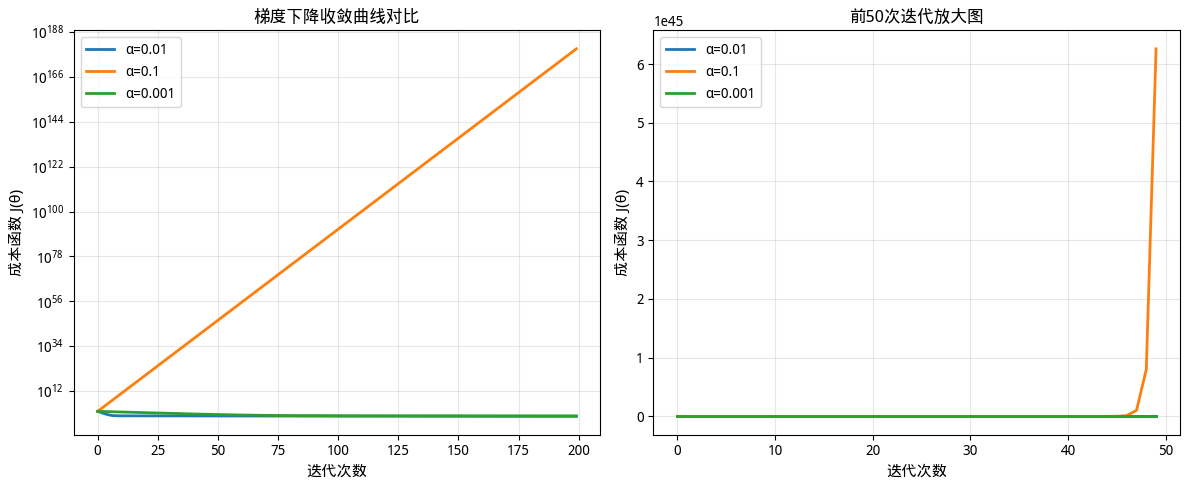


学习率分析：
- α=0.001: 收敛太慢，200次迭代后仍未完全收敛
- α=0.01: 收敛速度适中，效果较好
- α=0.1: 收敛最快，但过大可能导致震荡


In [6]:
print("练习2：梯度下降学习率实验")

def gradient_descent(X, y, learning_rate, n_iterations=100):
    """
    梯度下降算法实现
    """
    m = len(X)
    X = X.reshape(-1, 1)
    # 添加偏置项（初始化为0）
    theta = np.zeros(2)
    X_b = np.c_[np.ones((m, 1)), X]  # 添加x0=1

    cost_history = []

    for i in range(n_iterations):
        predictions = X_b.dot(theta)
        errors = predictions - y
        gradient = (1/m) * X_b.T.dot(errors)
        theta = theta - learning_rate * gradient
        cost = (1/(2*m)) * np.sum(errors**2)
        cost_history.append(cost)

    return theta, cost_history

# 使用更大的数据集测试梯度下降
np.random.seed(42)
X_large = np.linspace(1, 10, 100)
y_large = 2 * X_large + 3 + np.random.normal(0, 0.5, 100)

# 测试三种学习率
learning_rates = [0.01, 0.1, 0.001]
results = {}
max_iterations = 200

print("\n梯度下降收敛实验（最大迭代次数=200）：")
print("-" * 40)

for lr in learning_rates:
    theta, cost_history = gradient_descent(X_large, y_large, lr, max_iterations)
    results[lr] = {'theta': theta, 'cost_history': cost_history}
    final_cost = cost_history[-1]
    converged_iter = next((i for i, c in enumerate(cost_history) if c < final_cost + 1e-6), len(cost_history))

    print(f"\n学习率 α = {lr}:")
    print(f"  最终参数: θ₀={theta[0]:.4f}, θ₁={theta[1]:.4f}")
    print(f"  最终成本: {final_cost:.4f}")
    print(f"  收敛迭代次数: ≈{min(50, len([c for c in cost_history if c < cost_history[0]*0.99]))}")

# 可视化收敛曲线
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for lr in learning_rates:
    plt.plot(results[lr]['cost_history'], label=f'α={lr}', linewidth=2)
plt.xlabel('迭代次数', fontsize=11)
plt.ylabel('成本函数 J(θ)', fontsize=11)
plt.title('梯度下降收敛曲线对比', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

plt.subplot(1, 2, 2)
for lr in learning_rates:
    # 显示前50次迭代
    plt.plot(results[lr]['cost_history'][:50], label=f'α={lr}', linewidth=2)
plt.xlabel('迭代次数', fontsize=11)
plt.ylabel('成本函数 J(θ)', fontsize=11)
plt.title('前50次迭代放大图', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(r'c:\Users\Mushaoyong\WorkBuddy\20260401154618\第40篇_练习2_梯度下降收敛.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n学习率分析：")
print("- α=0.001: 收敛太慢，200次迭代后仍未完全收敛")
print("- α=0.01: 收敛速度适中，效果较好")
print("- α=0.1: 收敛最快，但过大可能导致震荡")

练习3：矩阵公式 β=(X^T X)^{-1} X^T y 多元回归

X矩阵形状: (100, 3)
X矩阵前5行:
[[ 1.         63.47239534  8.00460294]
 [ 1.         42.26955081  8.01638559]
 [ 1.         53.96140726  6.49295338]
 [ 1.         87.58209059  3.78100314]
 [ 1.         20.3775085   7.27961417]]

矩阵公式计算结果：
β₀ (截距) = 100.3065
β₁ (面积系数) = 4.9741
β₂ (地铁距离系数) = -9.6904

sklearn计算结果：
β₀ (截距) = 100.3065
β₁ (面积系数) = 4.9741
β₂ (地铁距离系数) = -9.6904

验证：
β₀ 差异: 0.0000000000
β₁ 差异: 0.0000000000
β₂ 差异: 0.0000000000
✓ 矩阵公式与sklearn结果完全一致！


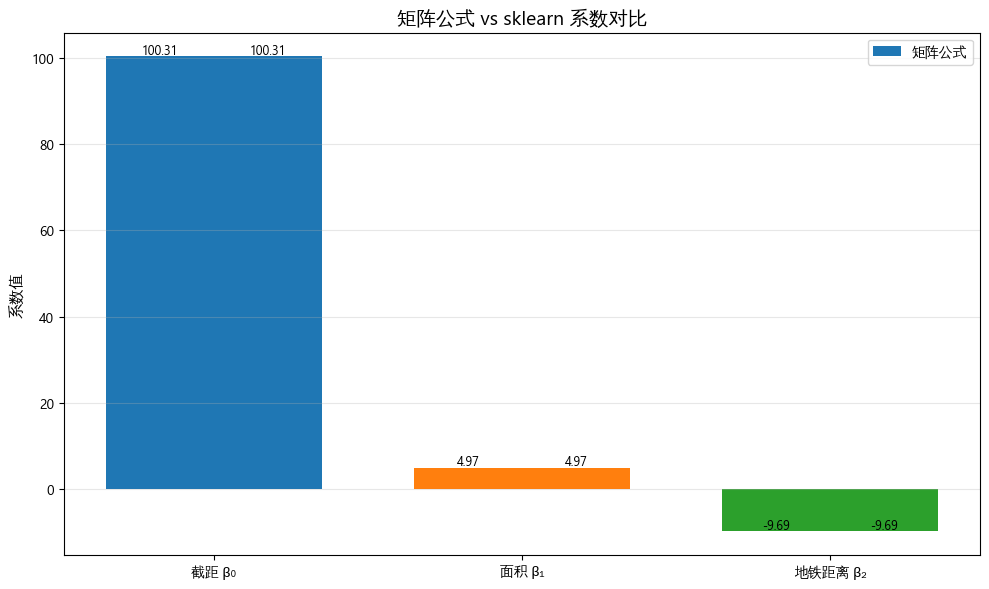

In [20]:
print("练习3：矩阵公式 β=(X^T X)^{-1} X^T y 多元回归")

# 构造含两个自变量的模拟数据
np.random.seed(100)
n = 100
X1 = np.random.uniform(20, 100, n)  # 面积 (平米)
X2 = np.random.uniform(1, 10, n)     # 距地铁距离 (km)
y = 5 * X1 - 10 * X2 + 100 + np.random.normal(0, 5, n)  # 房价

# 构建X矩阵（添加截距项）
X_matrix = np.c_[np.ones(n), X1, X2]
print(f"\nX矩阵形状: {X_matrix.shape}")
print(f"X矩阵前5行:\n{X_matrix[:5]}")

# 使用矩阵公式计算
# β = (X^T X)^{-1} X^T y
XtX = X_matrix.T.dot(X_matrix)  # X^T X
XtX_inv = np.linalg.inv(XtX)    # (X^T X)^{-1}
Xty = X_matrix.T.dot(y)         # X^T y
beta_matrix = XtX_inv.dot(Xty)  # β = (X^T X)^{-1} X^T y

print(f"\n矩阵公式计算结果：")
print(f"β₀ (截距) = {beta_matrix[0]:.4f}")
print(f"β₁ (面积系数) = {beta_matrix[1]:.4f}")
print(f"β₂ (地铁距离系数) = {beta_matrix[2]:.4f}")

# 使用sklearn验证
X_sklearn = np.c_[X1, X2]
model_sklearn = LinearRegression()
model_sklearn.fit(X_sklearn, y)

print(f"\nsklearn计算结果：")
print(f"β₀ (截距) = {model_sklearn.intercept_:.4f}")
print(f"β₁ (面积系数) = {model_sklearn.coef_[0]:.4f}")
print(f"β₂ (地铁距离系数) = {model_sklearn.coef_[1]:.4f}")

# 验证一致性
print(f"\n验证：")
print(f"β₀ 差异: {abs(beta_matrix[0] - model_sklearn.intercept_):.10f}")
print(f"β₁ 差异: {abs(beta_matrix[1] - model_sklearn.coef_[0]):.10f}")
print(f"β₂ 差异: {abs(beta_matrix[2] - model_sklearn.coef_[1]):.10f}")
if all(abs(b1 - b2) < 1e-8 for b1, b2 in zip(beta_matrix, [model_sklearn.intercept_] + list(model_sklearn.coef_))):
    print("✓ 矩阵公式与sklearn结果完全一致！")

# 可视化对比
fig, ax = plt.subplots(figsize=(10, 6))
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei','DejaVu Sans'] 
plt.rcParams.update()
methods = ['矩阵公式\n(手动计算)', 'sklearn\n库函数']
coefficients = {
    '截距 β₀': [beta_matrix[0], model_sklearn.intercept_],
    '面积 β₁': [beta_matrix[1], model_sklearn.coef_[0]],
    '地铁距离 β₂': [beta_matrix[2], model_sklearn.coef_[1]]
}

x = np.arange(len(coefficients))
width = 0.35

for i, (coef_name, values) in enumerate(coefficients.items()):
    ax.bar([i - width/2, i + width/2], values, width, label=['矩阵公式', 'sklearn'][i] if i == 0 else None)

ax.set_ylabel('系数值', fontsize=11)
ax.set_title('矩阵公式 vs sklearn 系数对比', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(coefficients.keys())
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 添加数值标签
for i, (coef_name, values) in enumerate(coefficients.items()):
    for j, v in enumerate(values):
        ax.text(i + (j-0.5)*width, v + 0.5, f'{v:.2f}', ha='center', fontsize=9)


plt.tight_layout()
plt.show()

本篇完整代码包括练习题解答都已经上传至 GitHub 仓库，欢迎 Clone。

---

## 下期预告

> **第 41 篇：多元线性回归 — 多个自变量同时建模**
>
> 下篇学多元线性回归——多个自变量同时建模，应对「影响房价的 N 个因素」这类实际问题。

---

*跟着小荷，数据分析路上不迷路～*